In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [ ]:
df = pd.read_excel('Telco_customer_churn.xlsx')
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:

null_counts = df.isnull().sum()
print(null_counts)


CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64


In [ ]:
df.nunique()

,0
CustomerID,7043
Count,1
Country,1
State,1
City,1129
Zip Code,1652
Lat Long,1652
Latitude,1652
Longitude,1651
Gender,2


In [ ]:
df.dtypes

,0
CustomerID,object
Count,int64
Country,object
State,object
City,object
Zip Code,int64
Lat Long,object
Latitude,float64
Longitude,float64
Gender,object


In [ ]:
from sklearn.cluster import KMeans


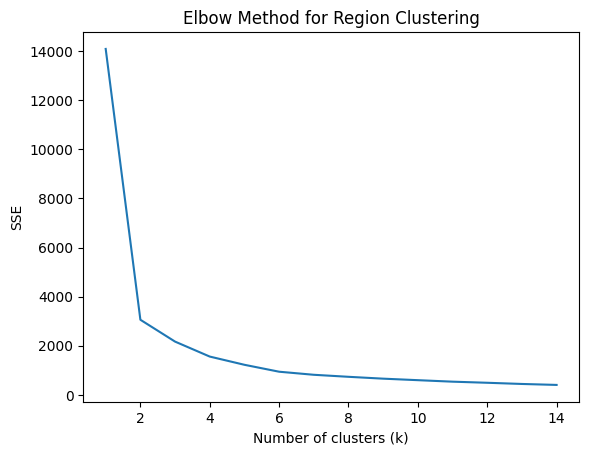

In [ ]:

location_data = df[['Latitude', 'Longitude']]


scaler = StandardScaler()
location_scaled = scaler.fit_transform(location_data)


sse = []
k_range = range(1, 15)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(location_scaled)
    sse.append(km.inertia_)

plt.figure()
plt.plot(k_range, sse)
plt.xlabel("Number of clusters (k)")
plt.ylabel("SSE")
plt.title("Elbow Method for Region Clustering")
plt.show()


In [ ]:
optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
df['RegionCluster'] = kmeans.fit_predict(location_scaled)

In [ ]:
df.drop(columns=[
    'CustomerID',
    'Count',
    'Country',
    'State',
    'City',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Churn Reason',
    'Churn Score',
    'CLTV',
    'Churn Label'
], inplace=True, errors='ignore')


In [ ]:
print(df['RegionCluster'].value_counts())

RegionCluster
1    3531
0    3512
Name: count, dtype: int64


In [ ]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,RegionCluster
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [ ]:
df.dtypes

,0
Gender,object
Senior Citizen,object
Partner,object
Dependents,object
Tenure Months,int64
Phone Service,object
Multiple Lines,object
Internet Service,object
Online Security,object
Online Backup,object


In [ ]:
df.nunique()

,0
Gender,2
Senior Citizen,2
Partner,2
Dependents,2
Tenure Months,73
Phone Service,2
Multiple Lines,3
Internet Service,3
Online Security,3
Online Backup,3


In [ ]:
for column in df.columns:
    unique_values = df[column].unique()
    print(f"\nColumn: {column}")
    print(unique_values)


Column: Gender
['Male' 'Female']

Column: Senior Citizen
['No' 'Yes']

Column: Partner
['No' 'Yes']

Column: Dependents
['No' 'Yes']

Column: Tenure Months
[ 2  8 28 49 10  1 47 17  5 34 11 15 18  9  7 12 25 68 55 37  3 27 20  4
 58 53 13  6 19 59 16 52 24 32 38 54 43 63 21 69 22 61 60 48 40 23 39 35
 56 65 33 30 45 46 62 70 50 44 71 26 14 41 66 64 29 42 67 51 31 57 36 72
  0]

Column: Phone Service
['Yes' 'No']

Column: Multiple Lines
['No' 'Yes' 'No phone service']

Column: Internet Service
['DSL' 'Fiber optic' 'No']

Column: Online Security
['Yes' 'No' 'No internet service']

Column: Online Backup
['Yes' 'No' 'No internet service']

Column: Device Protection
['No' 'Yes' 'No internet service']

Column: Tech Support
['No' 'Yes' 'No internet service']

Column: Streaming TV
['No' 'Yes' 'No internet service']

Column: Streaming Movies
['No' 'Yes' 'No internet service']

Column: Contract
['Month-to-month' 'Two year' 'One year']

Column: Paperless Billing
['Yes' 'No']

Column: Payment Met

In [ ]:
service_cols = [
    'Multiple Lines',
    'Online Security',
    'Online Backup',
    'Device Protection',
    'Tech Support',
    'Streaming TV',
    'Streaming Movies'
]

for col in service_cols:
    df[col] = df[col].replace({
        'No phone service': 'No',
        'No internet service': 'No'
    })


In [ ]:
for column in df.columns:
    unique_values = df[column].unique()
    print(f"\nColumn: {column}")
    print(unique_values)


Column: Gender
['Male' 'Female']

Column: Senior Citizen
['No' 'Yes']

Column: Partner
['No' 'Yes']

Column: Dependents
['No' 'Yes']

Column: Tenure Months
[ 2  8 28 49 10  1 47 17  5 34 11 15 18  9  7 12 25 68 55 37  3 27 20  4
 58 53 13  6 19 59 16 52 24 32 38 54 43 63 21 69 22 61 60 48 40 23 39 35
 56 65 33 30 45 46 62 70 50 44 71 26 14 41 66 64 29 42 67 51 31 57 36 72
  0]

Column: Phone Service
['Yes' 'No']

Column: Multiple Lines
['No' 'Yes']

Column: Internet Service
['DSL' 'Fiber optic' 'No']

Column: Online Security
['Yes' 'No']

Column: Online Backup
['Yes' 'No']

Column: Device Protection
['No' 'Yes']

Column: Tech Support
['No' 'Yes']

Column: Streaming TV
['No' 'Yes']

Column: Streaming Movies
['No' 'Yes']

Column: Contract
['Month-to-month' 'Two year' 'One year']

Column: Paperless Billing
['Yes' 'No']

Column: Payment Method
['Mailed check' 'Electronic check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Column: Monthly Charges
[ 53.85  70.7   99.65 ... 108.3

In [ ]:

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})


binary_cols = [
    'Senior Citizen', 'Partner', 'Dependents',
    'Phone Service', 'Multiple Lines', 'Online Security',
    'Online Backup', 'Device Protection', 'Tech Support',
    'Streaming TV', 'Streaming Movies', 'Paperless Billing'
]

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})


In [ ]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,RegionCluster
0,1,0,0,0,2,1,0,DSL,1,1,...,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1,1
1,0,0,0,1,2,1,0,Fiber optic,0,0,...,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1,1
2,0,0,0,1,8,1,1,Fiber optic,0,0,...,0,1,1,Month-to-month,1,Electronic check,99.65,820.5,1,1
3,0,0,1,1,28,1,1,Fiber optic,0,0,...,1,1,1,Month-to-month,1,Electronic check,104.80,3046.05,1,1
4,1,0,0,1,49,1,1,Fiber optic,0,1,...,0,1,1,Month-to-month,1,Bank transfer (automatic),103.70,5036.3,1,1


In [ ]:
df = pd.get_dummies(df, columns=['Internet Service', 'Contract', 'Payment Method'] , drop_first= True , dtype=int)

In [ ]:
df.dtypes

,0
Gender,int64
Senior Citizen,int64
Partner,int64
Dependents,int64
Tenure Months,int64
Phone Service,int64
Multiple Lines,int64
Online Security,int64
Online Backup,int64
Device Protection,int64


In [ ]:

df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')


In [ ]:
print(df['Total Charges'].isnull().sum())


11


In [ ]:
df = df[df['Total Charges'].notnull()]


In [ ]:
from sklearn.preprocessing import StandardScaler

num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges']
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


In [ ]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Online Security,Online Backup,Device Protection,...,Total Charges,Churn Value,RegionCluster,Internet Service_Fiber optic,Internet Service_No,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,1,0,0,0,-1.239504,1,0,1,1,0,...,-0.959649,1,1,0,0,0,0,0,0,1
1,0,0,0,1,-1.239504,1,0,0,0,0,...,-0.940457,1,1,1,0,0,0,0,1,0
2,0,0,0,1,-0.995040,1,1,0,0,1,...,-0.645369,1,1,1,0,0,0,0,1,0
3,0,0,1,1,-0.180161,1,1,0,0,1,...,0.336516,1,1,1,0,0,0,0,1,0
4,1,0,0,1,0.675462,1,1,0,1,1,...,1.214589,1,1,1,0,0,0,0,0,0


In [ ]:


X = df.drop('Churn Value', axis=1)
y = df['Churn Value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# After preprocessing, before splitting X/y
training_columns = df.drop(columns=['Churn Value']).columns.tolist()



In [ ]:
lr = LogisticRegression(random_state=42)

lr.fit(X_train, y_train)


y_pred = lr.predict(X_test)
y_proba = lr.predict_proba(X_test)[:,1]


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)



print("Logistic Regression Metrics:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Logistic Regression Metrics:
Accuracy: 0.8130774697938877
Precision: 0.7012195121951219
Recall: 0.5822784810126582
F1-score: 0.636237897648686


In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred)
precision_rf = precision_score(y_test, y_pred)
recall_rf = recall_score(y_test, y_pred)
f1_rf = f1_score(y_test, y_pred)

print("Random Forest Metrics:")
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-score:", f1_rf)

Random Forest Metrics:
Accuracy: 0.7945984363894811
Precision: 0.6766666666666666
Recall: 0.5139240506329114
F1-score: 0.5841726618705037


In [ ]:
metrics_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy, accuracy_rf],
    'Precision': [precision, precision_rf],
    'Recall': [recall, recall_rf],
    'F1-score': [f1, f1_rf]
})

print(metrics_df)

                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.813077   0.701220  0.582278  0.636238
1        Random Forest  0.794598   0.676667  0.513924  0.584173


In [ ]:
if accuracy_rf > accuracy:
    best_model = rf
else:
    best_model = lr

In [ ]:
import pandas as pd
import numpy as np

def predict_churn_user(best_model, scaler_numeric, kmeans, scaler_location, training_columns):
    """
    Real-time user input function for customer churn prediction.
    scaler_numeric: StandardScaler fitted on numeric features ['Tenure Months','Monthly Charges','Total Charges']
    scaler_location: StandardScaler fitted on ['Latitude','Longitude'] for KMeans clustering
    """
    print("Enter customer details:")

    # -------------------
    # 1️⃣ Collect user input
    # -------------------
    new_data = {
        'Gender': input("Gender (Male/Female): ").capitalize(),
        'Senior Citizen': input("Senior Citizen (Yes/No): ").capitalize(),
        'Partner': input("Partner (Yes/No): ").capitalize(),
        'Dependents': input("Dependents (Yes/No): ").capitalize(),
        'Tenure Months': input("Tenure Months: "),
        'Phone Service': input("Phone Service (Yes/No): ").capitalize(),
        'Multiple Lines': input("Multiple Lines (Yes/No): ").capitalize(),
        'Online Security': input("Online Security (Yes/No): ").capitalize(),
        'Online Backup': input("Online Backup (Yes/No): ").capitalize(),
        'Device Protection': input("Device Protection (Yes/No): ").capitalize(),
        'Tech Support': input("Tech Support (Yes/No): ").capitalize(),
        'Streaming TV': input("Streaming TV (Yes/No): ").capitalize(),
        'Streaming Movies': input("Streaming Movies (Yes/No): ").capitalize(),
        'Paperless Billing': input("Paperless Billing (Yes/No): ").capitalize(),
        'Monthly Charges': input("Monthly Charges: "),
        'Total Charges': input("Total Charges (leave blank to auto-fill): "),
        'Internet Service': input("Internet Service (DSL/Fiber optic/No): ").capitalize(),
        'Contract': input("Contract (Month-to-month/One year/Two year): ").capitalize(),
        'Payment Method': input("Payment Method (Electronic check/Mailed check/Bank transfer (automatic)/Credit card (automatic)): ").capitalize(),
        'Latitude': input("Latitude: "),
        'Longitude': input("Longitude: ")
    }

    user_df = pd.DataFrame([new_data])

    # -------------------
    # 2️⃣ Convert numeric columns
    # -------------------
    numeric_cols = ['Tenure Months','Monthly Charges','Total Charges','Latitude','Longitude']
    for col in numeric_cols:
        user_df[col] = pd.to_numeric(user_df[col], errors='coerce')

    # Fill missing numeric values
    user_df['Total Charges'] = user_df['Total Charges'].fillna(user_df['Monthly Charges'])
    user_df['Tenure Months'] = user_df['Tenure Months'].fillna(0)
    user_df['Monthly Charges'] = user_df['Monthly Charges'].fillna(0)
    user_df['Latitude'] = user_df['Latitude'].fillna(0)
    user_df['Longitude'] = user_df['Longitude'].fillna(0)

    # -------------------
    # 3️⃣ Clean service columns
    # -------------------
    service_cols = [
        'Multiple Lines', 'Online Security', 'Online Backup', 'Device Protection',
        'Tech Support', 'Streaming TV', 'Streaming Movies'
    ]
    for col in service_cols:
        user_df[col] = user_df[col].replace({'No phone service': 'No', 'No internet service': 'No'})

    # -------------------
    # 4️⃣ Binary encoding
    # -------------------
    user_df['Gender'] = user_df['Gender'].map({'Male':1,'Female':0}).fillna(0)
    binary_cols = [
        'Senior Citizen','Partner','Dependents','Phone Service','Multiple Lines',
        'Online Security','Online Backup','Device Protection','Tech Support',
        'Streaming TV','Streaming Movies','Paperless Billing'
    ]
    for col in binary_cols:
        user_df[col] = user_df[col].map({'Yes':1,'No':0}).fillna(0)

    # -------------------
    # 5️⃣ RegionCluster using scaled Latitude/Longitude
    # -------------------
    location_scaled = scaler_location.transform(user_df[['Latitude','Longitude']].values)
    user_df['RegionCluster'] = kmeans.predict(location_scaled)

    # -------------------
    # 6️⃣ One-hot encoding for categorical columns
    # -------------------
    ohe_cols = ['Internet Service','Contract','Payment Method']
    user_df = pd.get_dummies(user_df, columns=ohe_cols, drop_first=True, dtype=int)

    # -------------------
    # 7️⃣ Align columns with training data
    # -------------------
    for col in training_columns:
        if col not in user_df.columns:
            user_df[col] = 0
    user_df = user_df[training_columns]

    # -------------------
    # 8️⃣ Scale numeric columns
    # -------------------
    numeric_scale_cols = ['Tenure Months','Monthly Charges','Total Charges']
    user_df[numeric_scale_cols] = scaler_numeric.transform(user_df[numeric_scale_cols])

    # -------------------
    # 9️⃣ Predict churn
    # -------------------
    prediction = best_model.predict(user_df)[0]
    probability = best_model.predict_proba(user_df)[0,1]

    print(f"\nPredicted Churn: {'YES' if prediction==1 else 'NO'}")
    print(f"Churn Probability: {probability:.2f}")

    return prediction, probability


In [ ]:
# scaler_numeric = StandardScaler() fitted on ['Tenure Months','Monthly Charges','Total Charges']
# scaler_location = StandardScaler() fitted on ['Latitude','Longitude'] for KMeans
pred, prob = predict_churn_user(
    best_model=best_model,
    scaler_numeric=scaler,
    kmeans=kmeans,
    scaler_location=scaler_location,
    training_columns=training_columns
)


NameError: name 'scaler_location' is not defined